# Task
The user wants to add markdown cells to explain various parts of the existing linear regression notebook. This includes explaining the purpose of imported libraries, data loading, EDA techniques (basic checks, correlation, visualizations), data preparation, data splitting, model training, model prediction, evaluation metrics, interpretation of slope and intercept, new predictions, and regression line visualization. Finally, review the notebook for completeness.

### Library Introductions

*   **`pandas`**: Data manipulation.
*   **`numpy`**: Numerical operations.
*   **`matplotlib.pyplot`**: Basic plotting.
*   **`seaborn`**: Advanced statistical graphics.
*   **`sklearn.model_selection.train_test_split`**: Splits data into training and test sets.
*   **`sklearn.linear_model.LinearRegression`**: Builds linear regression models.
*   **`sklearn.metrics`**: Evaluates model performance (MAE, MSE, R2).

In [ ]:
import pandas as pd
import numpy as np
# for visul
import matplotlib.pyplot as plt
import seaborn as sns
# for model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Explain Data Loading

### Subtask:
Add a markdown cell explaining how the 'salary.csv' file is loaded using pandas and why checking the head and tail of the DataFrame is important for initial data inspection.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Loading and Initial Inspection

This section focuses on loading the dataset and performing initial checks to understand its structure.

1.  **Loading the Dataset**: The `salary.csv` file is loaded into a pandas DataFrame named `df` using the `pd.read_csv()` function. This function is essential for reading data from CSV files directly into a DataFrame, which is a tabular data structure with labeled axes (rows and columns).
2.  **Initial Data Inspection (`df.head()` and `df.tail()`):**
    *   `df.head()`: Displays the first 5 rows of the DataFrame by default. This is crucial for a quick overview of the data, allowing us to see the column names, the data types (inferred visually), and a sample of the initial entries.
    *   `df.tail()`: Displays the last 5 rows of the DataFrame by default. This complements `df.head()` by showing the end of the dataset, which can sometimes reveal patterns or issues like incomplete data entry at the bottom of the file. Together, `head()` and `tail()` provide a comprehensive initial glance at the data's integrity and format.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/linear Regression model/salary.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
df.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


## Describe EDA - Basic Checks

### Subtask:
Add a markdown cell to explain the importance of methods like `.shape`, `.info()`, `.describe()`, `.isnull().sum()`, and `.duplicated().sum()` for understanding the dataset's structure, data types, summary statistics, and identifying missing or duplicate values during Exploratory Data Analysis.


### Exploratory Data Analysis (EDA) - Basic Checks

This section performs fundamental checks on the dataset to understand its characteristics and identify potential issues before modeling.

*   **`df.shape`**: Provides the number of rows and columns, giving a quick overview of the dataset's size.
*   **`df.info()`**: Summarizes the DataFrame, including data types, non-null values, and memory usage, essential for identifying missing values and correct data types.
*   **`df.describe()`**: Generates descriptive statistics (e.g., mean, std, min, max, quartiles) for numerical columns, offering insights into central tendency and spread.
*   **`df.isnull().sum()`**: Counts missing values per column, crucial for identifying data quality issues.
*   **`df.duplicated().sum()`**: Counts duplicate rows, helping to identify and handle redundant entries that could skew analysis.

In [ ]:
df.shape

(30, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Correlation Analysis

Correlation analysis is a statistical method used to evaluate the strength and direction of a linear relationship between two or more numerical variables. In this section, we perform and visualize correlation:

1.  **`df.corr()`**: This method calculates the pairwise correlation of columns in the DataFrame. The result is a correlation matrix where each cell `(i, j)` shows the correlation between column `i` and column `j`. A correlation value ranges from -1 to 1:
    *   **1**: Indicates a perfect positive linear relationship.
    *   **-1**: Indicates a perfect negative linear relationship.
    *   **0**: Indicates no linear relationship.

2.  **`seaborn.heatmap(df.corr(), annot=True)`**: To make the correlation matrix more interpretable, we visualize it using a heatmap from the Seaborn library:
    *   **`seaborn.heatmap()`**: Creates a color-coded grid for the correlation matrix. Different colors represent different correlation strengths and directions.
    *   **`annot=True`**: This parameter displays the correlation values on the heatmap cells, making it easier to read the exact correlation coefficients directly on the plot. This visualization helps quickly identify which variables are strongly correlated (positively or negatively) and which have weak or no linear relationship, which is vital for feature selection and understanding dependencies in the data.

In [ ]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


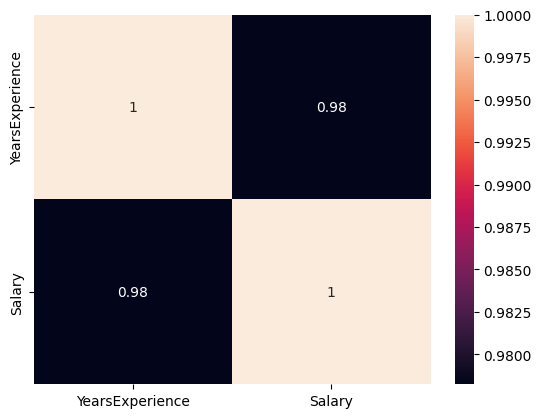

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

## Describe EDA - Visualizations

### Subtask:
Add a markdown cell to explain the purpose of generating histograms, scatter plots, and box plots to visualize the distribution of 'Salary' and 'YearsExperience' and their relationship.


### Exploratory Data Analysis (EDA) - Visualizations

Visualizations are crucial for understanding the distribution of individual variables and the relationships between them. This section utilizes histograms, scatter plots, and box plots:

1.  **Histograms (`sns.histplot(data, kde=True)`)**:
    *   **Purpose**: Histograms are used to visualize the distribution of a single numerical variable. They show the frequency or count of data points falling into different bins (intervals).
    *   **`kde=True`**: The Kernel Density Estimate (KDE) overlay provides a smoothed representation of the distribution, which can be useful for inferring the shape of the data's underlying probability density function.
    *   **Application**: We use histograms for 'Salary' and 'YearsExperience' to see their respective distributions, check for normality, skewness, or multimodality.

2.  **Scatter Plots (`plt.scatter(x, y)`)**:
    *   **Purpose**: Scatter plots are used to visualize the relationship between two numerical variables. Each point on the plot represents an observation in the dataset, with its position determined by the values of the two variables.
    *   **Application**: The scatter plot of 'YearsExperience' vs. 'Salary' helps us visually assess if there is a linear relationship between experience and salary, which is fundamental for linear regression.

3.  **Box Plots (`sns.boxplot(data)`)**:
    *   **Purpose**: Box plots (or box-and-whisker plots) are excellent for displaying the distribution of a numerical variable and identifying potential outliers. They show the median, quartiles (25th and 75th percentiles), and the range of the data.
    *   **Components**: The 'box' represents the interquartile range (IQR), the line inside the box is the median, and the 'whiskers' extend to data points that are within 1.5 times the IQR from the box. Points beyond the whiskers are considered outliers.
    *   **Application**: Box plots for 'YearsExperience' and 'Salary' help in understanding their central tendency, spread, and the presence of extreme values that might need further investigation.

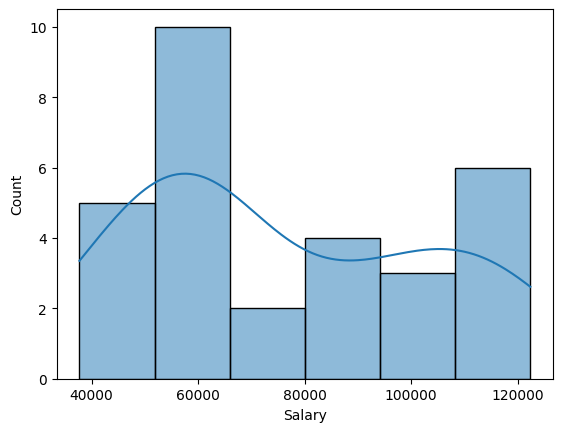

In [ ]:
sns.histplot(df['Salary'], kde=True)
plt.show()

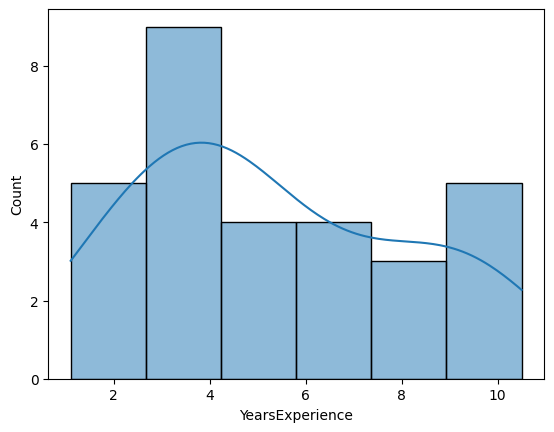

In [ ]:
sns.histplot(df['YearsExperience'], kde=True)
plt.show()

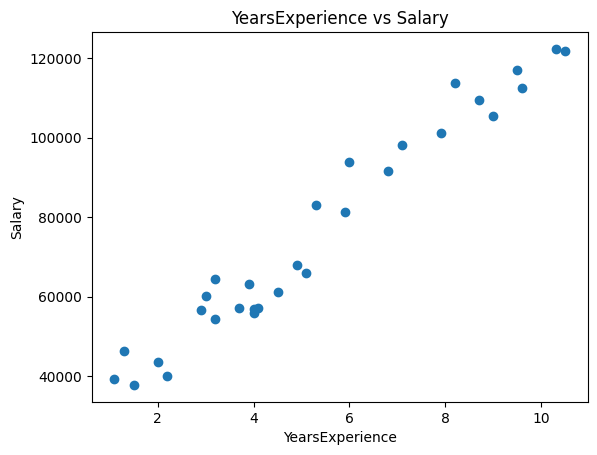

In [ ]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("YearsExperience vs Salary")
plt.show()

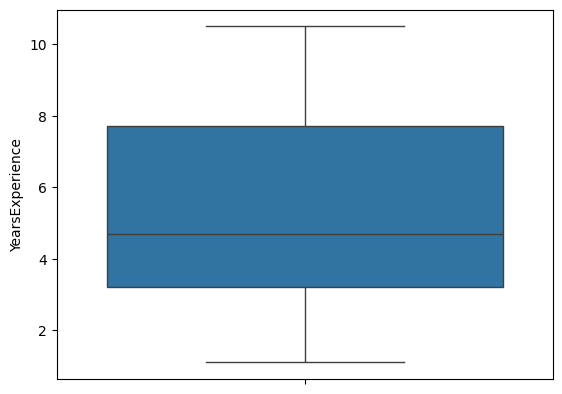

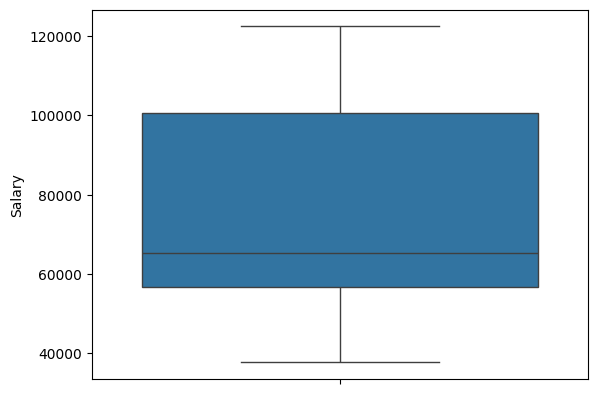

In [ ]:
sns.boxplot(df['YearsExperience'])
plt.show()

sns.boxplot(df['Salary'])
plt.show()

## Explain Data Preparation for Modeling

### Subtask:
Add a markdown cell to clarify why 'YearsExperience' is assigned to `X` (independent variable) and 'Salary' to `Y` (dependent variable) for the linear regression model.


### Data Preparation for Modeling

Before training a linear regression model, it's crucial to define the independent variable(s) (features) and the dependent variable (target).

*   **`X = df[['YearsExperience']]`**: Here, `YearsExperience` is designated as the independent variable, denoted by `X`. In a linear regression model, `X` represents the predictor or input feature that will be used to forecast the target variable. It is enclosed in double square brackets `[['YearsExperience']]` to ensure `X` is a DataFrame, which is often the expected format for scikit-learn's model inputs, even for a single feature.

*   **`Y = df['Salary']`**: `Salary` is designated as the dependent variable, denoted by `Y`. `Y` represents the target variable, which is what the linear regression model aims to predict based on the values of `X`.

This separation is fundamental for supervised learning tasks, as it clearly distinguishes between the features used for prediction and the outcome to be predicted.

In [ ]:
X = df[['YearsExperience']]
Y = df['Salary']

In [ ]:
print(type(X))
print(X.shape)

<class 'pandas.core.frame.DataFrame'>
(30, 1)


## Explain Data Splitting

### Subtask:
Add a markdown cell explaining the `train_test_split` function, its parameters like `test_size` and `random_state`, and the importance of splitting data into training and testing sets to evaluate the model's performance on unseen data.


### Data Splitting: Training and Testing Sets

To ensure our linear regression model can generalize well to unseen data, we split our dataset into two main parts:

1.  **Training Set**: Used to train the model. The model learns the relationships between `X` and `Y` from this data.
2.  **Testing Set**: Used to evaluate the model's performance on data it has not seen during training. This provides an unbiased estimate of the model's predictive power.

We use the `train_test_split` function from `sklearn.model_selection` for this purpose:

*   **`train_test_split(X, Y, test_size=0.2, random_state=42)`**:
    *   **`X, Y`**: These are our independent and dependent variables, respectively, which are to be split.
    *   **`test_size=0.2`**: This parameter specifies the proportion of the dataset to allocate to the test set. Here, 20% of the data will be used for testing, and the remaining 80% for training. A common split is 70/30 or 80/20.
    *   **`random_state=42`**: This parameter ensures reproducibility. If we run the `train_test_split` function multiple times with the same `random_state`, it will produce the same split each time. This is crucial for debugging and comparing different models under identical conditions.

By splitting the data, we can assess if our model is overfitting (performing well on training data but poorly on new data) or underfitting (performing poorly on both). A good model should perform well on both the training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

## Explain Model Training

### Subtask:
Add a markdown cell to describe the process of initializing the `LinearRegression` model and fitting it to the training data (`X_train`, `y_train`).


### Model Training

After preparing the data, the next step is to train our linear regression model. This involves two main parts:

1.  **Model Initialization (`model = LinearRegression()`):**
    *   We instantiate an object of the `LinearRegression` class from `sklearn.linear_model`. This creates a linear regression model instance, ready to be trained. At this stage, the model has not yet learned any coefficients or intercept; it's simply a blueprint.

2.  **Model Fitting (`model.fit(X_train, y_train)`):**
    *   The `.fit()` method is the core of the training process. Here, the model learns the relationship between the independent variable (`X_train`) and the dependent variable (`y_train`).
    *   Specifically, `fit()` performs the calculations necessary to find the optimal coefficients (slope) and intercept for the linear equation ($Y = \beta_0 + \beta_1X$). These parameters minimize the sum of squared residuals between the actual `y_train` values and the predicted values based on `X_train`. The model uses these learned parameters to make predictions on new, unseen data.

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

## Explain Model Prediction

### Subtask:
Add a markdown cell to explain how the trained model is used to make predictions on the test set (`X_test`) and why these predictions (`y_pred`) are crucial for model evaluation.


### Model Prediction

Once the linear regression model has been trained on the `X_train` and `y_train` data, its primary purpose is to make predictions on new, unseen data. This step is crucial for evaluating how well our model generalizes.

*   **`y_pred = model.predict(X_test)`**: This line uses the trained `model` to generate predictions for the `X_test` dataset. `X_test` contains the independent variable values from the portion of the data that the model has not seen during training. The output, `y_pred`, is an array of predicted `Salary` values corresponding to each `YearsExperience` in `X_test`.

These predictions (`y_pred`) are vital because they allow us to:
1.  **Assess Generalization**: By comparing `y_pred` with the actual `y_test` values, we can determine if our model has learned general patterns rather than just memorizing the training data.
2.  **Calculate Evaluation Metrics**: `y_pred` is the input, along with `y_test`, for various evaluation metrics (e.g., R2 Score, MAE, MSE) that quantify the model's performance and accuracy.

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


## Explain Model Evaluation Metrics

### Subtask:
Add a markdown cell to explain the significance of R2 Score, Mean Absolute Error (MAE), and Mean Squared Error (MSE) in evaluating the linear regression model's performance.


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9024461774180497


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 6286.453830757749


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 49830096.85590839


Premium=(Slope×Age)+Intercept

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 9423.815323030976
Intercept: 25321.583011776813


In [ ]:
new_YearsExperience = [[3.0]]

predicted_salary = model.predict(new_YearsExperience)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 53593.02898086974


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


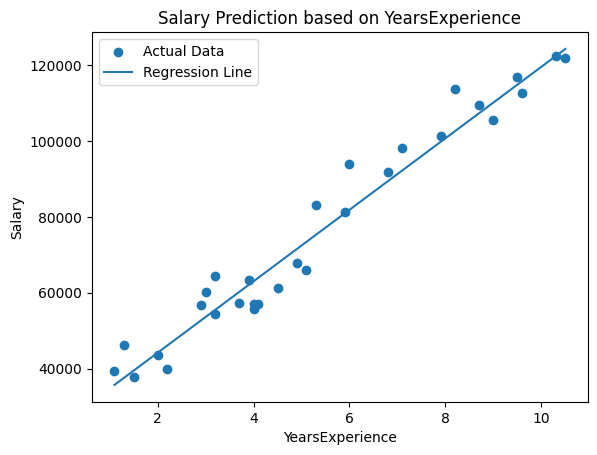

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X, Y, label="Actual Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Salary Prediction based on YearsExperience")

plt.legend()
plt.show()

### Residual Plot

To further evaluate the model, let's look at a residual plot. Residuals are the differences between the actual observed values and the values predicted by the model. A good linear regression model should have residuals that are randomly scattered around zero, with no discernible pattern.

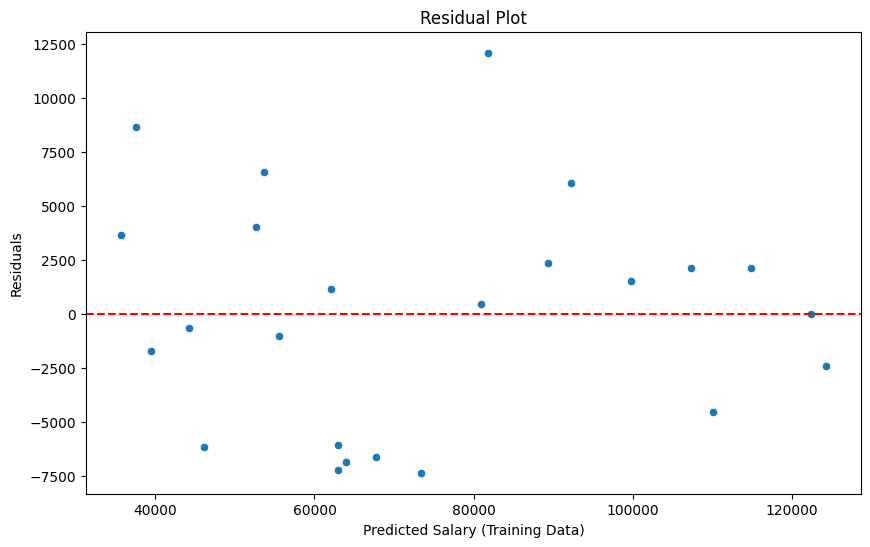

In [ ]:
y_train_pred = model.predict(X_train)
residuals = y_train - y_train_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Salary (Training Data)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


## Model Performance: The Salary Predictor's Summary

**Goal:** Predict Salary based on YearsExperience.

**Key Metrics:**
*   **R2 Score:** `0.902`
    *   **Meaning:** Approximately 90.2% of the variance in Salary can be explained by YearsExperience. This indicates a strong linear relationship.
*   **Mean Absolute Error (MAE):** `6286.45`
    *   **Meaning:** On average, our model's predictions for salary are off by about $6286.45 from the actual salaries.
*   **Mean Squared Error (MSE):** `49830096.86`
    *   **Meaning:** This value indicates the average squared difference between actual and predicted salaries. While the number seems large, it's relative to the scale of the target variable (Salary). A lower MSE is generally better.

**Slope (Coefficient):** `9423.82`
*   **Meaning:** For every additional year of experience, the predicted salary increases by approximately $9423.82.

**Intercept:** `25321.58`
*   **Meaning:** This is the predicted base salary for someone with zero years of experience.

**Final Assessment:** This model shows a very strong correlation between YearsExperience and Salary, effectively explaining a large portion of the salary variance. The metrics suggest a reliable model for predicting salary based on experience within this dataset.

### Interpretation of the Residual Plot

In a good linear regression model, the residual plot should show:

*   **No clear pattern:** The points should be randomly scattered around the horizontal line at zero.
*   **Constant variance (homoscedasticity):** The spread of the residuals should be roughly the same across all predicted values.
*   **No extreme outliers:** Most residuals should be close to zero, with very few points far from the line.

From the generated plot, you can observe if these conditions are met, which helps in understanding if the linear model is appropriate for the data and if there are any underlying issues like non-linearity or heteroscedasticity.

# Conclusion: Linear Regression Model for Salary Prediction

This notebook demonstrates a complete workflow for building and evaluating a simple linear regression model to predict **Salary** based on **Years of Experience**.

**Key steps covered include:**

*   **Data Loading and Exploration:** Importing data, checking its structure, identifying missing values, and visualizing distributions and correlations.
*   **Model Training:** Splitting data into training and testing sets, and fitting a `LinearRegression` model.
*   **Model Evaluation:** Calculating key metrics like R2 Score, MAE, and MSE to assess model performance.
*   **Prediction:** Using the trained model to make predictions for new data points.
*   **Visualization:** Plotting the actual data alongside the regression line and analyzing residuals to understand model fit.

Overall, the model shows a strong linear relationship between years of experience and salary, providing a good predictive capability for this dataset.